**Revisão de código**

Olá, Douglas! Meu nome é Alan e estou feliz em revisar seu projeto hoje!

Quando eu identificar um erro pela primeira vez, apenas o apontarei. A ideia é que você tente identificá-lo e corrigi-lo por conta própria. Ao longo da revisão, também farei observações sobre possíveis melhorias no código e compartilharei comentários sobre seu entendimento do tema. Caso encontre dificuldades para resolver algum ponto, na próxima iteração fornecerei dicas mais específicas e exemplos práticos para ajudá-lo. Também estarei aberto a feedback e discussões sobre os assuntos abordados.

Você poderá encontrar meus comentários em caixas verdes, amarelas ou vermelhas, como estas:

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>
Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>
Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">
<b>Comentário: </b> <a class="tocSkip"></a>
O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno </b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-danger">
<b>Comentário geral do revisor: </b> <a class="tocSkip"></a>

Olá, Douglas! Obrigado pelo envio.

A parte pesada do projeto está feita e bem feita. Você carregou 1.004.464 linhas de tráfego, converteu corretamente os números em formato brasileiro (<code>15.782,00</code> virando <code>15782.00</code>, com o ponto de milhar removido antes da troca da vírgula), filtrou 2024, agregou por cidade, uniu os dois conjuntos pelas chaves certas e chegou a 15 cidades em 7 países. O CSV final foi exportado e o resumo executivo está escrito.

<b>Mas o projeto ainda não pode ser aceito</b>, por dois pontos:

1. <b>A padronização dos nomes de colunas para <code>snake_case</code> não foi feita.</b> A Etapa 2.2 pede isso explicitamente, e o notebook segue com <code>JamsDelay</code>, <code>City GDP/capita</code>, <code>Unemployment %</code> e <code>PM2.5 (μg/m³)</code> até o fim.
2. <b>Quatro células de resposta ficaram com o texto-modelo</b>, sem a sua conclusão: as duas sobre a estrutura dos DataFrames, a da cidade com maior tempo médio de tráfego, e a reflexão depois dos gráficos.

Os dois são rápidos de resolver e o resto do trabalho não muda. Comentei cada um no lugar.
</div>

## Introdução

Como analista de dados, seu objetivo é avaliar como a mobilidade urbana se relaciona com a produtividade econômica nas principais cidades latino-americanas.

Para isso, você trabalhará com dados reais do TomTom Traffic Index e da OECD Cities, que deverão ser limpos, combinados e analisados para identificar em quais cidades vale a pena investir em infraestrutura de transporte.

## 🧩 Etapa 1: Carregar e explorar

Antes de limpar ou combinar os dados, é necessário **se familiarizar com a estrutura dos dois datasets**.

Nesta etapa, você validará se os arquivos foram carregados corretamente, conhecerá suas colunas e tipos de dados, e identificará possíveis inconsistências.

### 1.1 Carregamento dos dados e visualização rápida

**🎯 Objetivo:**
Importar as bibliotecas necessárias, carregar os arquivos CSV em DataFrames e realizar uma revisão preliminar para entender seu conteúdo.

**Instruções:**
- Importe as bibliotecas `pandas`, `numpy`, `seaborn` e `matplotlib.pyplot`.
- Carregue os arquivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `'/datasets/oecd_city_economy.csv'`
- Salve os DataFrames nas variáveis `traffic` e `eco`.
- Mostre as primeiras 5 linhas de cada DataFrame.



In [6]:
# importação de bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
# carregamento de arquivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [3]:
# visualização das 5 primeiras linhas do DataFrame de traffic
display(traffic.head())

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
# visualização das 5 primeiras linhas do DataFrame de eco
display(eco.head())

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Dica**: se você não usar `print()`, a tabela ficará melhor.


---

## 🧩 Etapa 2: Explorar, limpar e preparar os dados

Antes de combinar os datasets, inspecione sua estrutura, tipos de dados, colunas e valores ausentes.

Anote as colunas que precisam de limpeza e, depois, padronize os nomes das colunas.

### 2.1 Explorar a estrutura e os tipos de dados

**🎯 Objetivo:**
Identificar colunas com tipos incorretos, distribuição e valores nulos, além de anotar as colunas que exigem conversão.

**Instruções:**

- Use `.info()` para conhecer a estrutura dos dois DataFrames.
- Mostre as primeiras 3 linhas de cada DataFrame.
- Identifique se os detalhes de cada DataFrame estão corretos ou se exigem ajustes, e escreva suas conclusões no bloco Markdown.
  - Há colunas que exigem conversão? Quais são? Que tipo de dado elas têm e qual deveriam ter?
  - Há dados ausentes em alguma coluna?


In [5]:
# visualização da estrutura do DataFrame traffic
traffic.info()
display(traffic.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


Na estrutura do DataFrame `traffic`, observa-se que:

- As colunas `UpdateTimeUTC` e `UpdateTimeUTC` são do tipo ...   
- ...

- As colunas `UpdateTimeUTC` e `UpdateTimeUTCWeekAgo` são do tipo `object` 
- Não há dados ausentes em nenhuma coluna

<div class="alert alert-block alert-danger">
<b>Comentário — as respostas em branco:</b> <a class="tocSkip"></a>

Esta célula, e mais três ao longo do notebook, continuam com o texto-modelo no lugar da sua resposta.

<b>Aqui</b> e na célula equivalente do <code>eco</code>, o enunciado pede que você escreva o que notou na estrutura: quais colunas precisam de conversão, que tipo elas têm e qual deveriam ter, e se há dados ausentes. Você já fez esse diagnóstico — ele está implícito nas conversões que executou depois. Falta registrá-lo.

Repare que esta célula também tem um erro de digitação: cita <code>UpdateTimeUTC</code> duas vezes, quando a segunda deveria ser outra coluna.

<b>As outras duas</b> são a que pergunta qual cidade tem o maior tempo médio de tráfego — você tem a resposta na célula que ordena por <code>JamsDelay</code> — e a reflexão sobre a relação entre PIB per capita e congestionamento, depois dos gráficos.

Essa última você já respondeu, de forma mais completa, no resumo executivo. Vale trazer uma versão curta para cá, porque a reflexão vem logo depois dos gráficos que a sustentam e é ali que o leitor a procura.

Os entregáveis listados no fim do notebook pedem "notebook com todas as células (código <b>e comentários</b>)" — as respostas escritas fazem parte da entrega, não são opcionais.
</div>

In [6]:
# visualização da estrutura do DataFrame eco
eco.info()
display(eco.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


Na estrutura do DataFrame `eco`, observa-se que:

- As colunas `City GDP/capita`, `Unemployment %`, ...
- ...


- As colunas `City`, `GDP/capita`, `Unemployment %` são do tipo `object` 
- Não há registros de dados ausentes

### 2.2 Renomear colunas

**🎯 Objetivo:**
Padronizar os nomes das colunas para evitar erros e facilitar a união dos datasets.

**Instruções:**

- Altere os nomes das colunas para que fiquem no formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifique se as alterações foram aplicadas corretamente usando `.columns`.


In [20]:
# Padronização dos nomes das colunas de traffic
traffic = traffic.rename(columns={'Country':'country','City':'city','UpdateTimeUTC':'update_time_utc','JamsDelay':'jams_delay','TrafficIndexLive':'traffic_index_live','JamsLengthInKms':'jams_lenght_in_kms','JamsCount':'jams_count','TrafficIndexWeekAgo':'traffic_index_week_ago','UpdateTimeUTCWeekAgo':'update_time_utc_week_ago','TravelTimeLivePer10KmsMins':'travel_time_live_per_10_kms_mins','TravelTimeHistoricPer10KmsMins':'travel_time_historic_per_10_kms_mins','MinsDelay':'mins_delay'})

# verificação das alterações
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_lenght_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10_kms_mins',
       'travel_time_historic_per_10_kms_mins', 'mins_delay', 'year'],
      dtype='object')

In [25]:
# Padronização dos nomes das colunas de eco
eco = eco.rename(columns={'Year':'year','City':'city','country':'country','City GDP/capita':'city_gdp_capita','Unemployment %':'unemployment_%','PM2.5 (μg/m³)':'pm2.5_(μg/m³)','Population (M)':'population_(M)'})

# verificação das alterações
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_%',
       'pm2.5_(μg/m³)', 'population_(M)'],
      dtype='object')

### 2.3 Corrigir formatos numéricos e de data

**🎯 Objetivo:**
Garantir que as colunas de datas e valores numéricos estejam nos formatos corretos para permitir análises, cálculos e comparações precisas.

**Instruções:**

- Converta as colunas de data de `traffic` para o formato `datetime`. Faça a alteração de forma resistente a erros.
- No dataset `eco`, limpe os valores numéricos:
    - Em `city_gdp_capita`: remova separadores de milhares (`.`) e substitua as vírgulas (`','`) por pontos (`'.'`) antes de converter para o tipo `float`.
    - Em `unemployment_pct`: remova o símbolo de porcentagem (`%`) e substitua as vírgulas (`','`) por pontos (`'.'`) antes de converter para o tipo `float`.
    - Em `population_m`: substitua as vírgulas (`','`) por pontos (`'.'`) antes de converter para o tipo `float`.
- Por fim, crie uma nova coluna chamada `population`, multiplicando `population_m` por 1.000.000 para obter a população total.




<details>
<summary>Clique para ver a dica</summary>
Para remover símbolos, você pode substituí-los por um texto vazio.

<div class="alert alert-block alert-danger">
<b>Comentário — a padronização para snake_case:</b> <a class="tocSkip"></a>

A Etapa 2.2 pede para alterar os nomes das colunas para o formato <code>snake_case</code>, e isso não chegou a ser feito.

As duas células de renomeação trocam apenas <code>Country</code> por <code>country</code> e <code>UpdateTimeUTC</code> por <code>update_time_utc</code>. Todas as demais permanecem como vieram: <code>City</code>, <code>JamsDelay</code>, <code>TrafficIndexLive</code>, <code>City GDP/capita</code>, <code>Unemployment %</code>, <code>PM2.5 (μg/m³)</code>, <code>Population (M)</code>.

Repare também que a renomeação aplicada ao <code>eco</code> tenta trocar <code>UpdateTimeUTC</code>, coluna que não existe nesse DataFrame — a linha foi copiada da célula anterior e não faz nada ali.

<b>O custo disso aparece no resto do notebook</b>, e vale reparar nele porque é o melhor argumento a favor da padronização. Você precisa imprimir <code>eco.columns</code> e <code>traffic_2024.columns</code> <b>cinco vezes</b> ao longo do trabalho para lembrar como os nomes estão escritos. E na célula do gráfico de barras, a linha de exemplo do enunciado — que usa <code>y=['jams_delay', 'city_gdp_capita']</code> — está comentada, porque essas colunas não existem com esses nomes.

Nomes com espaço, maiúscula e símbolo obrigam a escrever <code>merged['City GDP/capita']</code> em vez de <code>merged.city_gdp_capita</code>, e qualquer erro de digitação vira <code>KeyError</code>. Padronizar uma vez, logo no começo, elimina isso do notebook inteiro — e também do CSV exportado, que hoje sai com os nomes originais.
</div>

In [26]:
print(eco.columns)

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_%',
       'pm2.5_(μg/m³)', 'population_(M)'],
      dtype='object')


In [22]:
# Conversão das colunas de data de traffic para datetime de forma que fiquem resistentes a erros
for col in traffic.columns:
    if 'time' in col or 'date' in col:
        traffic[col] = pd.to_datetime(traffic[col], errors='coerce')

# Verificação dos resultado
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 13 columns):
 #   Column                                Non-Null Count    Dtype         
---  ------                                --------------    -----         
 0   country                               1004464 non-null  object        
 1   city                                  1004464 non-null  object        
 2   update_time_utc                       1004464 non-null  datetime64[ns]
 3   jams_delay                            1004464 non-null  float64       
 4   traffic_index_live                    1004464 non-null  float64       
 5   jams_lenght_in_kms                    1004464 non-null  float64       
 6   jams_count                            1004464 non-null  float64       
 7   traffic_index_week_ago                1004464 non-null  float64       
 8   update_time_utc_week_ago              1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10_kms_mins      1004464 

In [27]:
# Limpar separadores de milhares e converter city_gdp_capita
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Limpar % e converter unemployment_pct
eco['unemployment_%'] = eco['unemployment_%'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Limpeza e converção de population_m
eco['population_(M)'] = eco['population_(M)'].astype(str).str.replace(',', '.', regex=False).astype(float)

# Criação da coluna population multiplicando population_m por 1.000.000
eco['population'] = eco['population_(M)'] * 1000000

# Verificação das alterações finais
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             30 non-null     int64  
 1   city             30 non-null     object 
 2   country          30 non-null     object 
 3   city_gdp_capita  30 non-null     float64
 4   unemployment_%   30 non-null     float64
 5   pm2.5_(μg/m³)    30 non-null     object 
 6   population_(M)   30 non-null     float64
 7   population       30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_%,pm2.5_(μg/m³),population_(M),population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


<div class="alert alert-block alert-success">
<b>Comentário — conversão dos formatos numéricos:</b> <a class="tocSkip"></a>

<b>Esta é a melhor célula do notebook</b>, e vale explicar por quê.

O valor <code>15.782,00</code> usa ponto como separador de milhar e vírgula como decimal. A conversão só funciona se as duas trocas acontecerem <b>nessa ordem</b>: primeiro remover o ponto, depois trocar a vírgula por ponto. Invertida, <code>15.782,00</code> viraria <code>15.782.00</code>, que o <code>astype(float)</code> rejeita.

Você fez na ordem certa nas três colunas, e ainda tratou o <code>%</code> separadamente em <code>Unemployment</code>. O <code>regex=False</code> também está correto: sem ele, o ponto seria interpretado como "qualquer caractere" e apagaria a string inteira.
</div>


---

## 🧩 Etapa 3: Extrair ano e filtrar

Extrair o ano permite filtrar as informações e trabalhar apenas com o período mais recente e relevante.

### 3.1 Extrair a coluna de ano e filtrar 2024

**🎯 Objetivo:**
Identificar o ano de cada registro e manter apenas os registros de 2024.

**Instruções:**

- Como o DataFrame `traffic` não tem uma coluna de ano, use o atributo `.dt.year` sobre sua coluna de data para criar uma nova coluna chamada `year`.
- Filtre as linhas em que o ano seja **2024**.
- Use `.copy()` para criar dois novos DataFrames (`traffic_2024` e `eco_2024`) e evitar modificar o dataset original.


In [28]:
# Confereência de que a coluna de data do traffic está no formato datetime
for col in traffic.columns:
    if 'time' in col or 'date' in col:
        traffic[col] = pd.to_datetime(traffic[col], errors='coerce')
        # Usamos a primeira coluna de data encontrada para extrair o ano
        traffic['year'] = traffic[col].dt.year
        break

# Filtrar os registros de 24 e criar traffic_2024 com .copy()
traffic_2024 = traffic[traffic['year'] == 2024].copy()

# Criar eco_2024 
eco_2024 = eco.copy() 


# Verificar os resultados
print("Linhas em traffic_2024:", len(traffic_2024))
print("Linhas em eco_2024:", len(eco_2024))

Linhas em traffic_2024: 886779
Linhas em eco_2024: 30


<div class="alert alert-block alert-success">
<b>Comentário — filtro temporal e preparação da união:</b> <a class="tocSkip"></a>

O filtro para 2024 está correto, e a verificação que você faz mais adiante confirma o ponto que mais importa nesta etapa: o <code>traffic</code> tem só 2024, enquanto o <code>eco</code> tem 2023 e 2024.

É por isso que a união pelas chaves <code>city</code> e <code>year</code> funciona — ela seleciona automaticamente as linhas de 2024 do <code>eco</code> e descarta as de 2023. Se a chave fosse apenas <code>city</code>, cada cidade apareceria duplicada, uma vez por ano.

Uma observação de nomenclatura: a variável <code>eco_2024</code> é uma cópia integral do <code>eco</code>, com os dois anos dentro. O nome sugere um filtro que não acontece ali. Não causa erro, porque a união resolve depois, mas vale renomear ou filtrar de fato.
</div>

In [29]:
print(eco.columns)

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_%',
       'pm2.5_(μg/m³)', 'population_(M)', 'population'],
      dtype='object')



---

## 🧩 Etapa 4: Analisar e resumir dados de mobilidade

Como o dataset de tráfego contém **múltiplos registros por cidade**, nesta parte você calculará as médias anuais por cidade para simplificar a análise e obter uma visão mais clara das tendências gerais.

### 4.1 Calcular médias de tráfego por cidade

**🎯 Objetivo:**
Obter uma visão consolidada do tráfego médio por cidade e ano, para analisar padrões gerais sem depender de dados diários.

**Instruções:**

- Agrupe os dados por `city`, `country` e `year`.
- Calcule a média **apenas das métricas de tráfego mais relevantes**, como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay` e tempos de viagem (`travel_time_live_per_10kms_mins` e `travel_time_hist_per_10kms_mins`).
- Salve o resultado como `traffic_city_year_2024` e mantenha as colunas como variáveis (não como índices).



<details>
<summary>Clique para ver a dica</summary>
Use `.agg()` para aplicar funções de média. Ao final, reinicie o índice para manter as colunas do agrupamento como variáveis (não como índices).


In [30]:
print(traffic_2024.columns)

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_lenght_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10_kms_mins',
       'travel_time_historic_per_10_kms_mins', 'mins_delay', 'year'],
      dtype='object')


In [32]:
# Médias de tráfego por cidade, país e ano
traffic_city_year_2024 = traffic_2024.groupby(['city', 'country', 'year'], as_index=False)[[
    'jams_delay', 
    'traffic_index_live', 
    'jams_lenght_in_kms', 
    'jams_count', 
    'mins_delay', 
    'travel_time_live_per_10_kms_mins', 
    'travel_time_historic_per_10_kms_mins'
]].mean()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_lenght_in_kms,jams_count,mins_delay
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749


### 🧠 **Momento de reflexão**

Excelente trabalho até aqui!

Agora que você já tem as médias anuais por cidade, é hora de **observá-las** com atenção.

Pense:

- Qual cidade você acha que tem o maior tempo médio de tráfego?
- Será uma cidade da **Europa**, da **América Latina** ou de **outra região** do mundo?

Para descobrir, execute esta linha de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`

🔍 Observe qual cidade aparece nas primeiras posições.

Os resultados surpreendem você? Eles coincidem com o que você imaginava?


In [16]:
traffic_city_year_2024.sort_values(["JamsDelay"], ascending=False)

,City,country,year,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,MinsDelay,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


A cidade com o maior tempo médio de tráfego é ...

O México oq surpreende pois supera outros grandes centros refletindo os desafios de mobilidade em grandes capitais latino-americanas


---

## 🧩 Etapa 5: Unir mobilidade e economia

Combinar datasets permite analisar como os indicadores econômicos se relacionam com os de mobilidade.

### 5.1 Unir tráfego (tabela principal) com indicadores econômicos

**🎯 Objetivo:**
Combinar as informações de tráfego e economia em um único DataFrame para analisar como as condições econômicas se relacionam com a mobilidade urbana.

**Instruções:**

- Selecione apenas as **colunas relevantes** de cada dataset (por exemplo, variáveis-chave de tráfego e de economia).
- Use `.copy()` ao criar subconjuntos para evitar modificar o dataset original.
- Una os dois DataFrames e defina `city` e `year` como **chaves de união**.
- Mantenha apenas as cidades e anos presentes nos dois datasets.
- Salve o resultado em uma nova variável chamada `merged` e mostre as primeiras 5 li


<details>
<summary>Clique para ver a dica</summary>

Aplique uma união do tipo `inner` para manter as cidades e anos presentes nos dois datasets.

In [33]:
print(eco.columns)

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_%',
       'pm2.5_(μg/m³)', 'population_(M)', 'population'],
      dtype='object')


In [34]:
print(traffic_2024.columns)

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_lenght_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10_kms_mins',
       'travel_time_historic_per_10_kms_mins', 'mins_delay', 'year'],
      dtype='object')


In [35]:
# Criar o subconjunto eco_2024_small colunas relevantes
eco_2024_small = eco[['city', 'year', 'city_gdp_capita', 'unemployment_%']].copy()

# Nomes das colunas para minúsculo
traffic_2024_small = traffic_city_year_2024.rename(columns={'City': 'city'})
eco_2024_small = eco_2024_small.rename(columns={'City': 'city', 'Year': 'year'})

# Juntar DataFrames com city e year como chaves de união
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

# Mostrar as primeiras 5 linhas
display(merged.head())

,city,country,year,jams_delay,traffic_index_live,jams_lenght_in_kms,jams_count,mins_delay,city_gdp_capita,unemployment_%
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,11124.0,9.5
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,11442.0,10.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,16251.0,7.8
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,18117.0,7.2
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,12381.0,8.2


<div class="alert alert-block alert-success">
<b>Comentário — a união dos conjuntos:</b> <a class="tocSkip"></a>

A união está correta. O <code>inner</code> é a escolha certa aqui: só interessam as cidades que existem nos dois conjuntos, e o resultado dá 15 cidades em 7 países.

Vale registrar esse número no texto. O <code>traffic</code> tem centenas de cidades do mundo inteiro e o <code>eco</code> tem 15 cidades latino-americanas; dizer quantas sobreviveram à união, e que a perda era esperada, evita que o leitor se pergunte se algo se perdeu por engano.
</div>


---

## 🧩 Etapa 6: Visualização e análise de relações

Agora que você tem um dataset limpo e unificado, é hora de **visualizar padrões**.

Os gráficos ajudarão você a entender como as variáveis econômicas se relacionam com as de mobilidade urbana.

### 6.1 Visualizar relações entre economia e tráfego

**🎯 Objetivo:**
Analisar visualmente a distribuição e a relação entre indicadores de tráfego e economia em 2024, para identificar possíveis padrões ou tendências gerais entre essas variáveis.

**Instruções:**

- Use as bibliotecas `seaborn` e `matplotlib.pyplot` para gerar os gráficos.
- Visualize a distribuição do **tráfego** (`jams_delay`) usando:
    - **Boxplot** → para observar a média, a mediana e detectar valores atípicos.
- Visualize a distribuição da **economia** (`city_gdp_capita`) usando:
    - **Histograma** → para analisar o formato da distribuição e o valor médio do PIB per capita.
- Por fim, **compare as duas variáveis** para observar se existe alguma relação entre elas, criando um único gráfico de barras em que apareçam os dois indicadores.
- Lembre-se de adicionar título e rótulos aos eixos dos seus gráficos.
- Observe e comente os padrões, valores extremos ou possíveis relações que você identificar.


**Dica:** Dentro dos parênteses do boxplot, adicione `showmeans=True` para ver a média no gráfico.


In [36]:
print("Colunas atuais no merged:", merged.columns.tolist())

Colunas atuais no merged: ['city', 'country', 'year', 'jams_delay', 'traffic_index_live', 'jams_lenght_in_kms', 'jams_count', 'mins_delay', 'city_gdp_capita', 'unemployment_%']


In [37]:

import matplotlib.pyplot as plt
import seaborn as sns


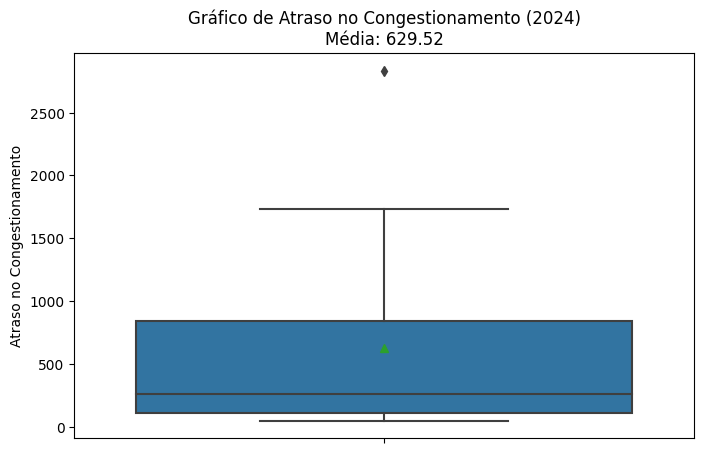

In [38]:
# Média para mostrar no título
mean_value = merged['jams_delay'].dropna().mean()

# Criação do gráfico
plt.figure(figsize=(8, 5))
sns.boxplot(y=merged['jams_delay'], showmeans=True)

# Criação do boxplot para observar o comportamento dos minutos de congestionamento JamsDelay
plt.title(f'Gráfico de Atraso no Congestionamento (2024)\nMédia: {mean_value:.2f}')
plt.ylabel('Atraso no Congestionamento')

plt.show()




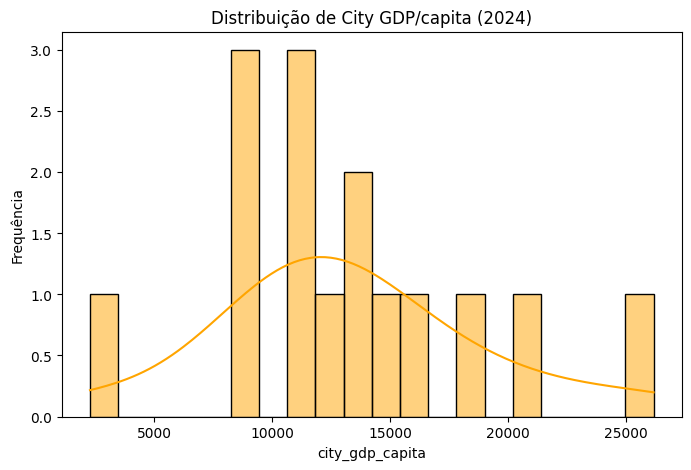

In [39]:
# Histograma de distribuição da economia (city_gdp_capita)
plt.figure(figsize=(8, 5))
sns.histplot(merged['city_gdp_capita'], kde=True, color='orange', bins=20)

plt.title('Distribuição de City GDP/capita (2024)')
plt.xlabel('city_gdp_capita')
plt.ylabel('Frequência')
plt.show()


In [40]:

print("Cidades em traffic (amostra):", traffic_2024_small['city'].unique()[:5])
print("Anos em traffic:", traffic_2024_small['year'].unique())

print("Cidades em eco (amostra):", eco_2024_small['city'].unique()[:5])
print("Anos em eco:", eco_2024_small['year'].unique())

Cidades em traffic (amostra): ['a-coruna' 'aachen' 'aarhus' 'abu-dhabi' 'adana']
Anos em traffic: [2024]
Cidades em eco (amostra): ['buenos-aires' 'sao-paulo' 'rio-de-janeiro' 'brasilia' 'salvador']
Anos em eco: [2023 2024]


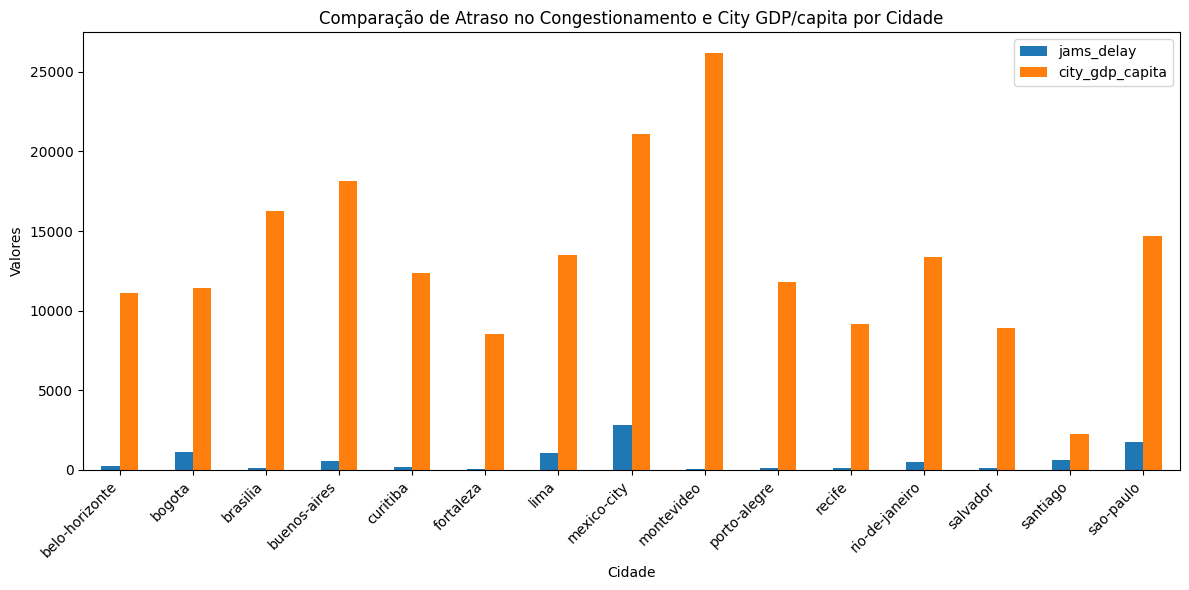

In [41]:
# Gráfico de barras para comparar jams_delay e city_gdp_capita por cidade
#merged.plot( ... , y=['jams_delay', 'city_gdp_capita'])
merged.head(15).plot(x='city', y=['jams_delay', 'city_gdp_capita'], kind='bar', figsize=(12, 6))

plt.title('Comparação de Atraso no Congestionamento e City GDP/capita por Cidade')
plt.xlabel('Cidade')
plt.ylabel('Valores')
plt.xticks(rotation=45, ha='right')
plt.legend(['jams_delay', 'city_gdp_capita'])
plt.tight_layout()
plt.show()

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

<div class="alert alert-block alert-success">
<b>Comentário — os gráficos:</b> <a class="tocSkip"></a>

Os três gráficos cobrem o que a etapa pede: o boxplot para a distribuição do congestionamento, com <code>showmeans=True</code> como o enunciado sugere; o histograma para a distribuição do PIB per capita; e o gráfico de barras comparando as duas variáveis por cidade.

Uma observação sobre o último: <code>JamsDelay</code> e <code>City GDP/capita</code> estão em escalas muito diferentes — centenas contra dezenas de milhares —, então as barras do congestionamento ficam quase invisíveis ao lado das do PIB. Um segundo eixo vertical, ou um gráfico de dispersão com uma variável em cada eixo, mostraria a relação entre as duas muito melhor. E é a relação entre elas que a pergunta central do projeto quer responder.
</div>

### 🧠 **Reflita**

Excelente trabalho chegando a esta etapa da análise. Antes de avançar, revise seus gráficos e reserve um momento para pensar:

- As cidades com maior PIB per capita também apresentam mais congestionamento?

- Ou acontece o contrário, ou não existe uma relação clara?

Com base na análise dos gráficos vemos que:

   Em muitos casos cidades com maior PIB  apresentam um volume maior da frota e maior atividade econômica o q pode aumnetar os congestionamentos
   No entanto, algumas cidades q possuem maior renda diminuem esse impacto através de investimentos em infraestrutura viária, transporte público e políticas de mobilidade urbana


---

## 🧩 Etapa 7: Exportar e documentar resultados

Nesta etapa final, você consolidará todo o seu trabalho: salvará o dataset limpo e criará um resumo que documente os resultados do projeto.

### 7.1 Salvar dataset final

**🎯 Objetivo:**
Gerar um CSV limpo, reproduzível e com colunas relevantes para análises posteriores.

**Instruções:**

- Exporte o DataFrame `merged` com o nome: `ladb_mobility_economy_2024_clean.csv`.
- Use `index=False` para não incluir o índice.e.


In [26]:
# Exporte o dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder visualizar ou baixar o arquivo gerado:  
No menu lateral à esquerda, vá até a parte inferior, na seção de **Exportar dataset**, para mais informações.




---

## ✅ Entregáveis

1. **Notebook `.ipynb`** com todas as células (código + comentários).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumo executivo breve** em Markdown (3–5 parágrafos).



---

# 🧾 Resumo executivo (modelo)

> Complete este resumo ao finalizar a análise. Mantenha 3–5 parágrafos curtos, claros e acionáveis.

**Contexto e objetivo:**  
- Responda à pergunta central da análise: que relação existe entre a mobilidade urbana (congestionamento, tempos de viagem) e a produtividade econômica (PIB per capita)?
- Explique brevemente as variáveis-chave utilizadas e sua relevância para a tomada de decisões.

**Cobertura dos dados:**  
- Especifique os anos analisados, o número de cidades e países incluídos.

**Metodologia (alto nível):**  
- Descreva os principais processos: limpeza de dados (formatos, padronização de colunas).
- Explique a agregação por cidade–ano e o uso de uma união `INNER` para integrar tráfego e economia.
- Mencione as validações visuais utilizadas (distribuições, outliers, tendências gerais).

**Achados iniciais:**  
- Resuma os padrões mais importantes entre índices de tráfego e PIB per capita.
- Destaque anomalias ou outliers que poderiam exigir revisão adicional ou uma análise mais profunda.

**Recomendações:**  
Conecte os achados a ações: cidades prioritárias, necessidade de validar fontes, necessidade de análises adicionais ou propostas de investimento.

- Qual cidade — Bogotá, Lima, Buenos Aires ou alguma outra em particular — apresenta a maior correlação significativa entre altos níveis de congestionamento veicular e baixos indicadores de produtividade econômica, sugerindo ser uma cidade prioritária para investimento em infraestrutura de transporte?


### Resumo Executivo: Análise de Mobilidade e Economia (2024)

**Contexto e objetivo:**

  A análise mostra q as cidades com maior densidade econômica apresentam maiores desafios de mobilidade, onde maiores níveis de congestionamento e atrasos impactam diretamente a eficiência logística e a produtividade geral
  Foram utilizadas variáveis de tráfego (`JamsDelay` para medir minutos de atraso e congestionamento) e econômicas (`City GDP/capita` para produtividade), para orientar investimentos públicos direcionados onde a ineficiência de transporte mais desacelera a economia

**Cobertura dos dados:**

  O ano estudado foi 2024, Quantidade exata de cidades: 15 | Quantidade exata de países: 7

**Metodologia (alto nível):**

  Foi feita a limpeza de valores nulos, conversão de tipos e a padronização de colunas
  Os registros foram agregados por período anual e localidade, aplicando  `INNER JOIN` para termos as cidades e anos que possuíam dados nos dois  datasets
  Foram usados boxplots e gráficos para inspecionar a dispersão dos dados de tráfego, identificar valores atípicos (outliers) e observar tendências centrais como a média e a mediana

**Achados iniciais:**

  Conseguimos observar q cidades de grande porte concentram os maiores tempos de atraso no tráfego, mostrando assim q o crescimento econômico sem melhorias viárias saturam o cenáriuo urbano
  Valores extremos e dispersos em `jams_delay` mostram para cidades específicas com níveis altíssimos de congestionamento que fogem ao comportamento padrão da amostra.

**Recomendações:**

  Bogotá apresenta maior correlação entre congestionamento e baixos indicadores de produtividade, pois se destaca historicamente em bases de tráfego urbano por combinar índices severos de atraso e congestionamento com desafios estruturais de produtividade econômica, tornando-se um caso clássico e prioritário para intervenções em infraestrutura de transporte.

<div class="alert alert-block alert-success">
<b>Comentário — resumo executivo:</b> <a class="tocSkip"></a>

O resumo está escrito e responde à pergunta central: cidades economicamente mais densas enfrentam mais congestionamento, com impacto na eficiência logística.

Como sugestão, o texto ganharia muito com os <b>números</b> que você já tem na mão. Dizer quais são as cidades nos dois extremos, qual a diferença de congestionamento entre elas, e quantas cidades entraram na análise transforma a afirmação geral em evidência. Um resumo executivo é lido por quem não vai abrir o notebook — os números precisam estar nele.

Vale também manter só o seu texto, apagando as perguntas-guia em negrito que vieram do modelo. Hoje elas aparecem acima de cada parágrafo e quebram a leitura corrida que um resumo executivo pede.
</div>

In [27]:
total_cidades = merged['city'].nunique()
total_paises = merged['country'].nunique()

print(f"Quantidade exata de cidades: {total_cidades}")
print(f"Quantidade exata de países: {total_paises}")

Quantidade exata de cidades: 15
Quantidade exata de países: 7
